In [4]:
!pip install mlxtend

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.6 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.



   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 339.3 kB/s eta 0:00:03
   --------------- ------------------------ 0.5/1.4 MB 339.3 kB/s eta 0:00:03
   --------------- ------------------------ 0.5/1.4 MB 339.3 kB/s eta 0:00:03
   ----------------------- ---------------- 0.8/1.4 MB 380.5 kB/s eta 0:00:02
   ----------------------- ---------------- 0.8/1.4 MB 380.5 kB/s eta 0:00:02
   ----------------------- ---------------- 0.8/1.4 MB 380.5 kB/s eta 0:00:02
   ------------------------------ --------- 1.0/

In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [9]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


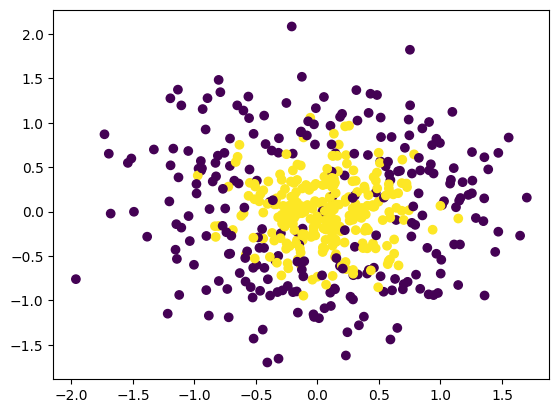

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.812)

In [12]:
abc.fit(X,y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.39,0.41,0.38,...,0.48,0.48,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.44,0.34,0.47,...,0.1 ,0.09,0.1 ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...state=6512440), DecisionTreeC...ate=549302307), DecisionTreeC...te=1281168044), DecisionTreeC...ate=834400275), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](2,)","[0.54,0.46]"


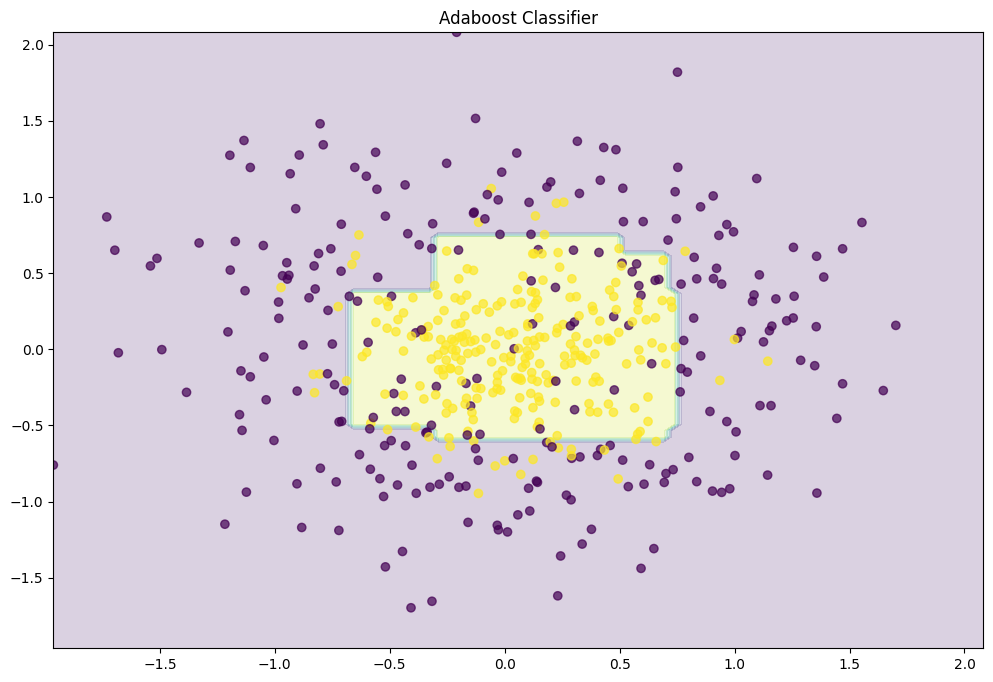

In [13]:

def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    
plot_decision_boundary(abc)

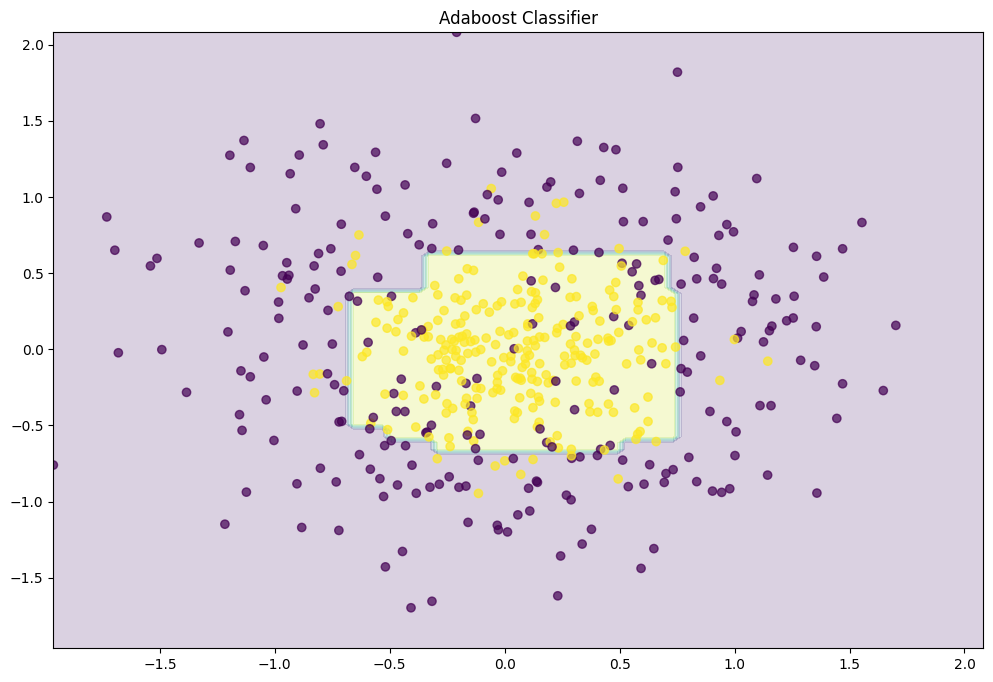

In [15]:

abc = AdaBoostClassifier(n_estimators=1500,learning_rate=0.1)
abc.fit(X,y)
plot_decision_boundary(abc)